# Pertemuan 03 - Linear Regression

| | |
|---|---|
| **Nama** | Andre Firmansyah |
| **NIM** | 105841101123 |
| **Mata Kuliah** | Machine Learning |
| **Topik** | Linear Regression |

---
##  Tujuan

Pada pertemuan ini, tujuan yang ingin dicapai adalah:
1. Memahami dan mengimplementasikan **Simple Linear Regression** menggunakan satu fitur beserta visualisasi garis regresinya.
2. Mengimplementasikan **Multiple Linear Regression** menggunakan minimal tiga fitur.
3. Membandingkan performa model **Polynomial Degree 1 vs Degree 2** untuk melihat mana yang lebih sesuai dengan data.
4. Mengevaluasi setiap model menggunakan metrik **MAE**, **RMSE**, dan **R²**.

---
##  Langkah Kerja

Berikut adalah alur pengerjaan notebook ini:
1. Import semua library yang dibutuhkan
2. Membuat dataset acak menggunakan NumPy
3. Melatih model Simple Linear Regression dan memvisualisasikan hasilnya
4. Melatih model Multiple Linear Regression dengan 3 fitur
5. Membandingkan model Polynomial Degree 1 dan Degree 2
6. Menyimpulkan hasil berdasarkan nilai metrik evaluasi

---
##  Import Library

Langkah pertama adalah mengimpor semua library yang diperlukan. `numpy` dan `pandas` digunakan untuk mengolah data, `matplotlib` untuk visualisasi, sedangkan semua modul dari `sklearn` digunakan untuk membangun model regresi dan menghitung metrik evaluasi.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

---
## 1. Simple Linear Regression

Simple Linear Regression adalah model regresi paling dasar yang hanya menggunakan **satu fitur (X)** untuk memprediksi satu nilai target (y). Model ini mencari garis lurus terbaik yang merepresentasikan hubungan antara X dan y.

### Pembuatan Dataset

Dataset dibuat secara acak menggunakan `numpy`. Nilai X diambil secara random dalam rentang 0–10, kemudian nilai y dibuat berdasarkan persamaan linear sederhana ditambah sedikit noise (gangguan acak) agar data terlihat lebih realistis.

In [2]:
np.random.seed(42)
X_simple = np.random.rand(100, 1) * 10
y_simple = 3 * X_simple.squeeze() + np.random.randn(100) * 2 + 5

print(f'Jumlah data : {len(X_simple)}')
print(f' X    : {X_simple[:3].flatten()}')
print(f' y    : {y_simple[:3]}')

Jumlah data : 100
 X    : [3.74540119 9.50714306 7.31993942]
 y    : [16.4102977  32.92341449 27.14333981]


### Pelatihan Model

Data dibagi menjadi data latih (80%) dan data uji (20%) menggunakan `train_test_split`. Setelah itu, model `LinearRegression` dari sklearn dilatih menggunakan data latih, lalu digunakan untuk memprediksi data uji.

In [3]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)
y_pred_s = model_simple.predict(X_test_s)

print(f'Koefisien (slope) : {model_simple.coef_[0]:.4f}')
print(f'Intercept         : {model_simple.intercept_:.4f}')

Koefisien (slope) : 2.9197
Intercept         : 5.2858


### Visualisasi Garis Regresi

Scatter plot di bawah menunjukkan sebaran data asli (titik biru), sedangkan garis merah adalah garis regresi yang dihasilkan oleh model. Semakin dekat titik-titik data ke garis merah, semakin baik model dalam menangkap pola data.

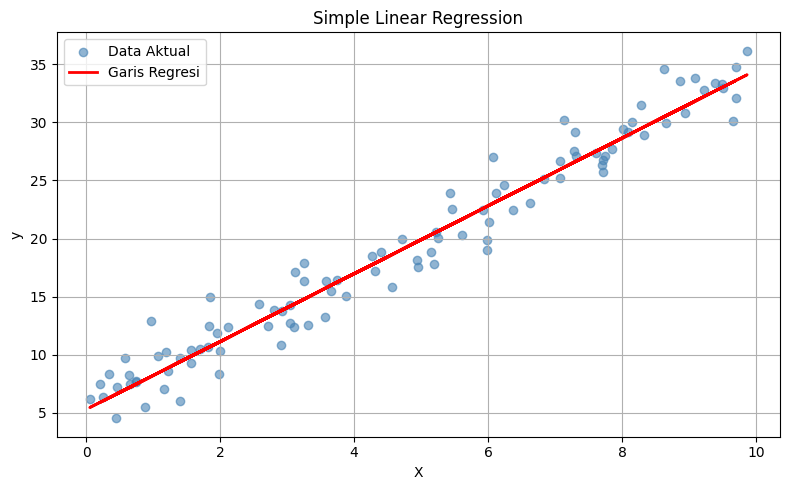

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(X_simple, y_simple, color='steelblue', alpha=0.6, label='Data Aktual')
plt.plot(X_simple, model_simple.predict(X_simple), color='red', linewidth=2, label='Garis Regresi')
plt.title('Simple Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Evaluasi Model

Model dievaluasi menggunakan tiga metrik:
- **MAE** (Mean Absolute Error): rata-rata selisih absolut antara nilai prediksi dan nilai aktual
- **RMSE** (Root Mean Squared Error): akar dari rata-rata kuadrat selisih prediksi dan aktual, lebih sensitif terhadap error besar
- **R²**: menunjukkan seberapa besar variasi data yang bisa dijelaskan oleh model (semakin mendekati 1 semakin baik)

In [5]:
mae_s  = mean_absolute_error(y_test_s, y_pred_s)
rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
r2_s   = r2_score(y_test_s, y_pred_s)

print('=== Evaluasi Simple Linear Regression ===')
print(f'MAE  : {mae_s:.4f}')
print(f'RMSE : {rmse_s:.4f}')
print(f'R²   : {r2_s:.4f}')

=== Evaluasi Simple Linear Regression ===
MAE  : 1.1827
RMSE : 1.6170
R²   : 0.9686


---
## 2. Multiple Linear Regression

Multiple Linear Regression adalah pengembangan dari simple linear regression yang menggunakan **lebih dari satu fitur** sebagai input. Tujuannya adalah menangkap pengaruh beberapa variabel sekaligus terhadap target, sehingga prediksi bisa lebih akurat dibanding hanya menggunakan satu fitur.

### Pembuatan Dataset

Dataset dibuat dengan 3 fitur acak. Nilai target y dihitung berdasarkan kombinasi linear dari ketiga fitur tersebut dengan koefisien yang berbeda, ditambah noise acak untuk membuat data lebih bervariasi.

In [6]:
np.random.seed(42)
X_multi = np.random.rand(100, 3) * 10
y_multi = (2 * X_multi[:, 0] + 3.5 * X_multi[:, 1] - 1.5 * X_multi[:, 2]
           + np.random.randn(100) * 2 + 10)

df = pd.DataFrame(X_multi, columns=['Fitur_1', 'Fitur_2', 'Fitur_3'])
df['Target'] = y_multi
print('5 baris pertama dataset:')
df.head()

5 baris pertama dataset:


,Fitur_1,Fitur_2,Fitur_3,Target
0,3.745401,9.507143,7.319939,39.877038
1,5.986585,1.560186,1.559945,23.790704
2,0.580836,8.661761,6.011150,36.749000
3,7.080726,0.205845,9.699099,11.601099
4,8.324426,2.123391,1.818250,27.303062


### Pelatihan dan Evaluasi Model

Proses pelatihan sama seperti sebelumnya — data dibagi lalu model dilatih. Perbedaannya, kali ini X memiliki 3 kolom fitur sehingga model menghasilkan 3 koefisien, masing-masing mewakili pengaruh setiap fitur terhadap target.

In [7]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)
y_pred_m = model_multi.predict(X_test_m)

print(f'Koefisien setiap fitur : {model_multi.coef_}')
print(f'Intercept              : {model_multi.intercept_:.4f}')

mae_m  = mean_absolute_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mean_squared_error(y_test_m, y_pred_m))
r2_m   = r2_score(y_test_m, y_pred_m)

print('\n=== Evaluasi Multiple Linear Regression ===')
print(f'MAE  : {mae_m:.4f}')
print(f'RMSE : {rmse_m:.4f}')
print(f'R²   : {r2_m:.4f}')

Koefisien setiap fitur : [ 2.02117953  3.4849212  -1.36278815]
Intercept              : 9.8300

=== Evaluasi Multiple Linear Regression ===
MAE  : 2.2088
RMSE : 2.8407
R²   : 0.9522


---
## 3. Polynomial Regression: Degree 1 vs Degree 2

Tidak semua data memiliki hubungan yang linear. Polynomial Regression memungkinkan model menangkap pola yang **melengkung (non-linear)** dengan cara menambahkan fitur-fitur baru berupa pangkat dari fitur asli. Degree 1 sama dengan regresi linear biasa, sedangkan Degree 2 memungkinkan model membentuk kurva parabola.

### Pembuatan Dataset Non-linear

Dataset kali ini dibuat dengan pola kuadratik (y bergantung pada X²), sehingga seharusnya model degree 2 akan lebih cocok dibanding degree 1.

In [8]:
np.random.seed(42)
X_poly = np.sort(np.random.rand(100, 1) * 10, axis=0)
y_poly = 0.5 * X_poly.squeeze()**2 - 2 * X_poly.squeeze() + np.random.randn(100) * 3 + 10

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y_poly, test_size=0.2, random_state=42
)
print('Dataset polynomial berhasil dibuat.')

Dataset polynomial berhasil dibuat.


### Pelatihan Model Degree 1 dan Degree 2

Untuk Degree 1, model langsung dilatih seperti biasa. Untuk Degree 2, terlebih dahulu digunakan `PolynomialFeatures` untuk mengubah fitur X menjadi [1, X, X²], baru kemudian dimasukkan ke model Linear Regression.

In [9]:
# Degree 1
model_d1 = LinearRegression()
model_d1.fit(X_train_p, y_train_p)
y_pred_d1 = model_d1.predict(X_test_p)

# Degree 2
poly = PolynomialFeatures(degree=2)
X_train_p2 = poly.fit_transform(X_train_p)
X_test_p2  = poly.transform(X_test_p)

model_d2 = LinearRegression()
model_d2.fit(X_train_p2, y_train_p)
y_pred_d2 = model_d2.predict(X_test_p2)

print('Model Degree 1 dan Degree 2 berhasil dilatih.')

Model Degree 1 dan Degree 2 berhasil dilatih.


### Visualisasi Perbandingan

Grafik berikut memperlihatkan perbedaan bentuk kurva antara Degree 1 (garis lurus oranye) dan Degree 2 (kurva hijau). Terlihat bahwa Degree 2 mengikuti bentuk data lebih baik karena datanya memang memiliki pola melengkung.

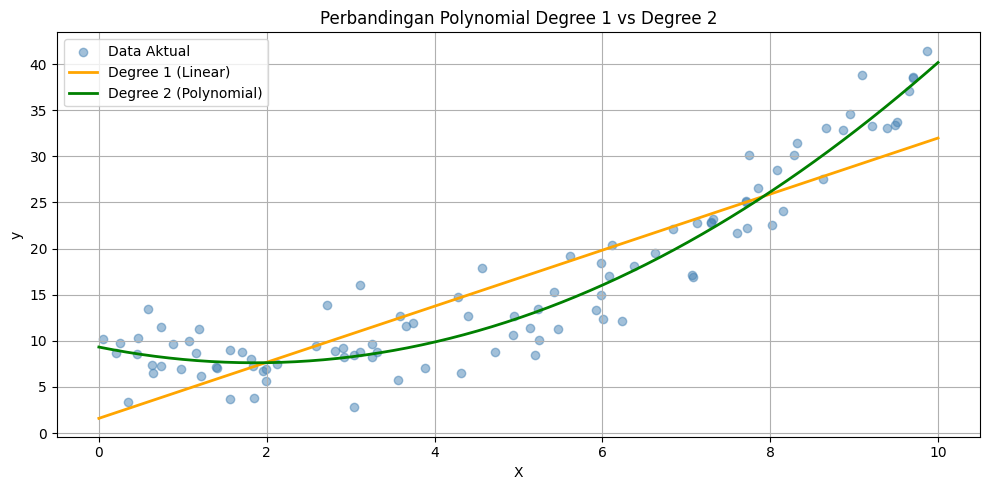

In [10]:
X_range    = np.linspace(0, 10, 300).reshape(-1, 1)
y_range_d1 = model_d1.predict(X_range)
y_range_d2 = model_d2.predict(poly.transform(X_range))

plt.figure(figsize=(10, 5))
plt.scatter(X_poly, y_poly, color='steelblue', alpha=0.5, label='Data Aktual')
plt.plot(X_range, y_range_d1, color='orange', linewidth=2, label='Degree 1 (Linear)')
plt.plot(X_range, y_range_d2, color='green',  linewidth=2, label='Degree 2 (Polynomial)')
plt.title('Perbandingan Polynomial Degree 1 vs Degree 2')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Evaluasi dan Perbandingan Metrik

Kedua model dievaluasi menggunakan metrik yang sama untuk mendapatkan perbandingan yang objektif. Model dengan MAE dan RMSE lebih kecil serta R² lebih besar menunjukkan performa yang lebih baik.

In [11]:
mae_d1  = mean_absolute_error(y_test_p, y_pred_d1)
rmse_d1 = np.sqrt(mean_squared_error(y_test_p, y_pred_d1))
r2_d1   = r2_score(y_test_p, y_pred_d1)

mae_d2  = mean_absolute_error(y_test_p, y_pred_d2)
rmse_d2 = np.sqrt(mean_squared_error(y_test_p, y_pred_d2))
r2_d2   = r2_score(y_test_p, y_pred_d2)

hasil = pd.DataFrame({
    'Model' : ['Degree 1', 'Degree 2'],
    'MAE'   : [mae_d1, mae_d2],
    'RMSE'  : [rmse_d1, rmse_d2],
    'R²'    : [r2_d1, r2_d2]
})
print('Tabel Perbandingan Metrik:')
hasil

Tabel Perbandingan Metrik:


,Model,MAE,RMSE,R²
0,Degree 1,3.582620,4.353353,0.740357
1,Degree 2,1.895991,2.498179,0.914498


---
##  Kesimpulan

Berdasarkan hasil percobaan yang telah dilakukan pada notebook ini, dapat disimpulkan beberapa hal:

1. **Simple Linear Regression** mampu memodelkan hubungan antara satu fitur dan target dengan cukup baik ketika data memiliki pola linear.

2. **Multiple Linear Regression** dengan 3 fitur menghasilkan nilai R² yang tinggi karena model dapat memanfaatkan informasi dari lebih banyak variabel sekaligus.

3. **Polynomial Degree 2** terbukti lebih baik dibanding Degree 1 pada data yang memiliki pola melengkung, ditunjukkan dengan nilai MAE dan RMSE yang lebih rendah serta R² yang lebih tinggi. Degree 1 mengalami *underfitting* karena hanya bisa membentuk garis lurus.

4. Pemilihan model yang tepat sangat bergantung pada **karakteristik data** — model harus mampu mengikuti pola yang ada tanpa terlalu sederhana (*underfitting*) maupun terlalu kompleks (*overfitting*).